**<head>PROJET MLOPS</head>**

In [40]:
# !pip install  statsmodels 
# !pip install xgboost
# !pip install scikit-learn
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install statsmodels
# !pip install scipy
# !pip install scikit-learn
# !pip install pandas


In [41]:
# Import necessary libraries
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
seeds = 42

In [42]:
# Load the dataset
data = pd.read_csv('Loan_data.csv')
#Desbribe the dataset
display(data.shape)
display(data.size)
displaydescribe = data.describe()

# Display the first few rows of the dataset
display(data.head())
display(displaydescribe)

(10000, 8)

80000

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [43]:
#Analyse des données manquantes
data.isnull().sum()
if data.isnull().sum().any():
    print("Il y a des données manquantes dans le dataset.")
else:
    print("Il n'y a pas de données manquantes dans le dataset.")

Il n'y a pas de données manquantes dans le dataset.


In [44]:
#Analyse des data types
display(data.dtypes)
#Analyse des valeurs uniques
for column in data.columns:
    unique_values = data[column].nunique()
    print(f"Colonne '{column}' a {unique_values} valeurs uniques.")
else:
    print("Aucune colonne n'a qu'une seule valeur unique.")

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

Colonne 'customer_id' a 10000 valeurs uniques.
Colonne 'credit_lines_outstanding' a 6 valeurs uniques.
Colonne 'loan_amt_outstanding' a 10000 valeurs uniques.
Colonne 'total_debt_outstanding' a 10000 valeurs uniques.
Colonne 'income' a 9995 valeurs uniques.
Colonne 'years_employed' a 11 valeurs uniques.
Colonne 'fico_score' a 374 valeurs uniques.
Colonne 'default' a 2 valeurs uniques.
Aucune colonne n'a qu'une seule valeur unique.


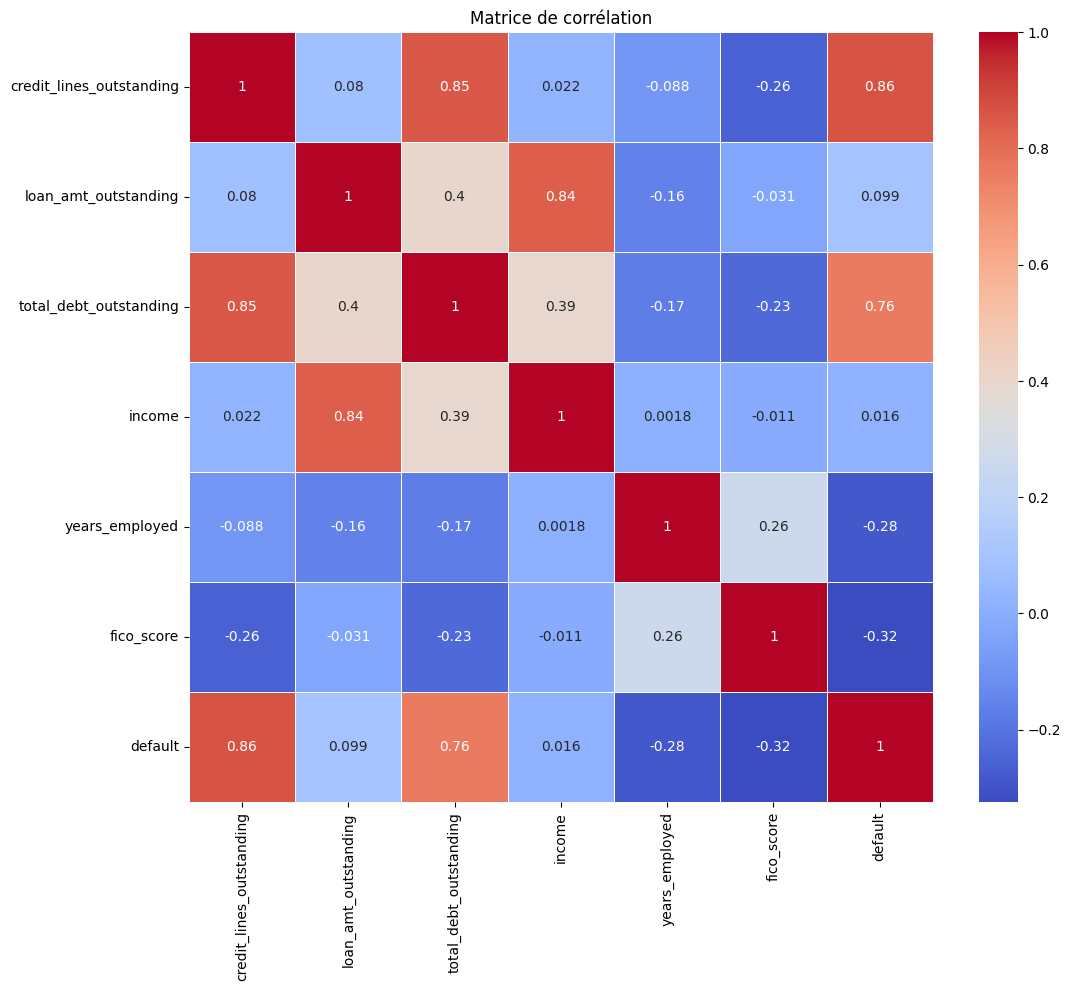

Correlations supérieures à 0,75 :


,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,1.000000,NaN,0.852210,NaN,NaN,NaN,0.862815
loan_amt_outstanding,NaN,1.000000,NaN,0.835815,NaN,NaN,NaN
total_debt_outstanding,0.852210,NaN,1.000000,NaN,NaN,NaN,0.758868
income,NaN,0.835815,NaN,1.000000,NaN,NaN,NaN
years_employed,NaN,NaN,NaN,NaN,1.0,NaN,NaN
fico_score,NaN,NaN,NaN,NaN,NaN,1.0,NaN
default,0.862815,NaN,0.758868,NaN,NaN,NaN,1.000000


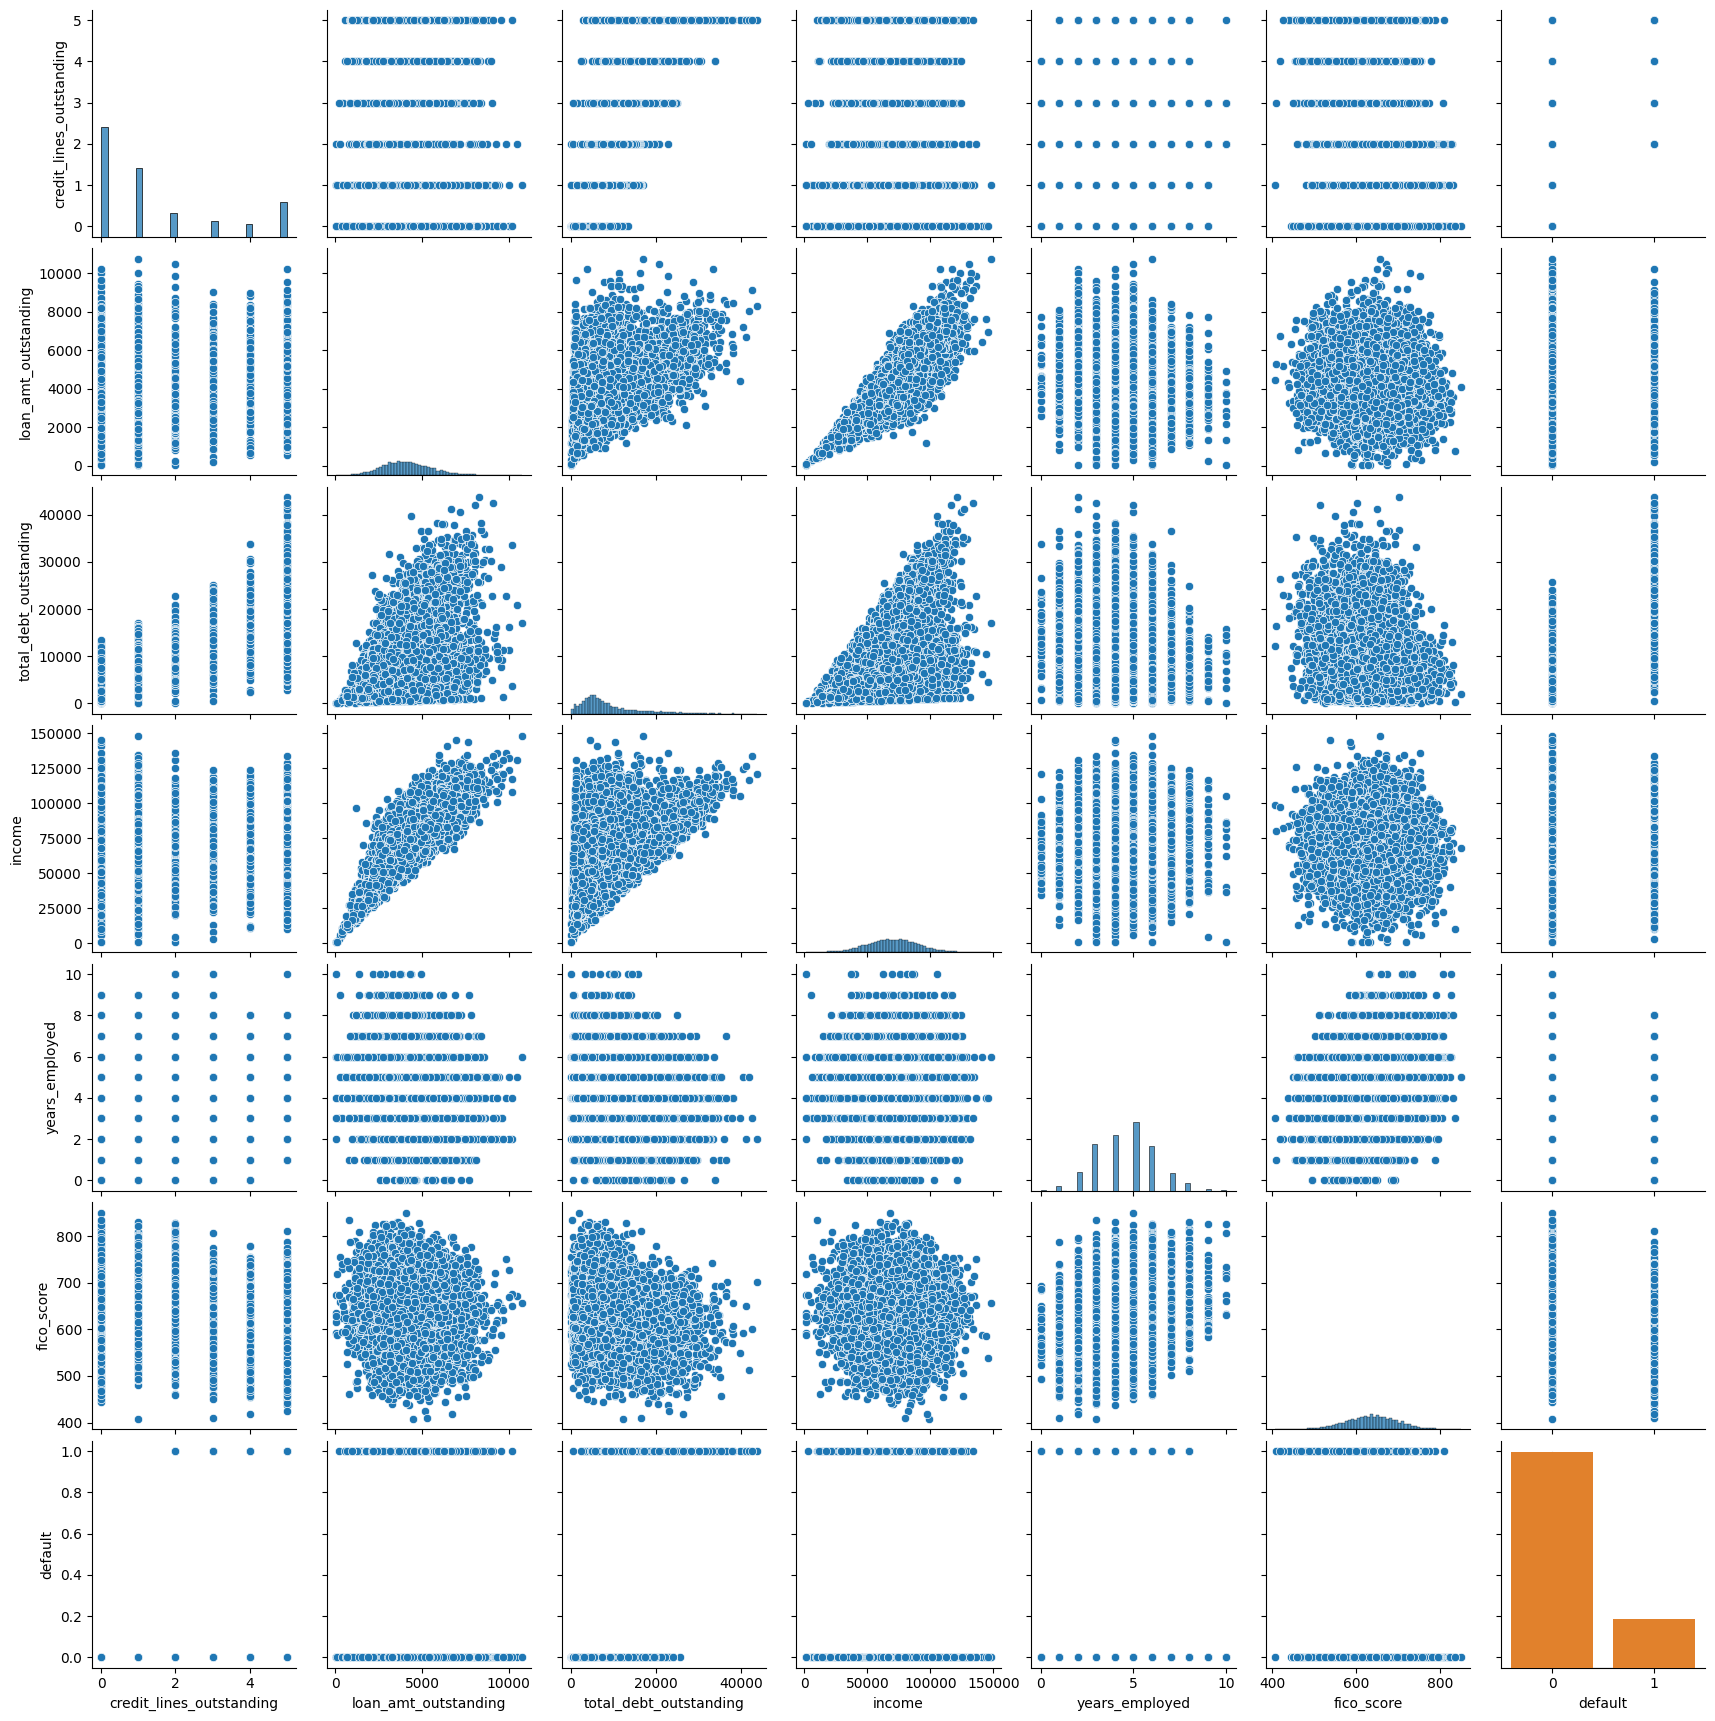

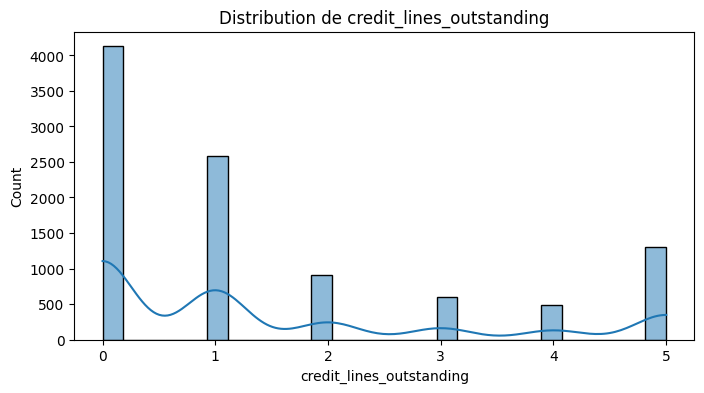

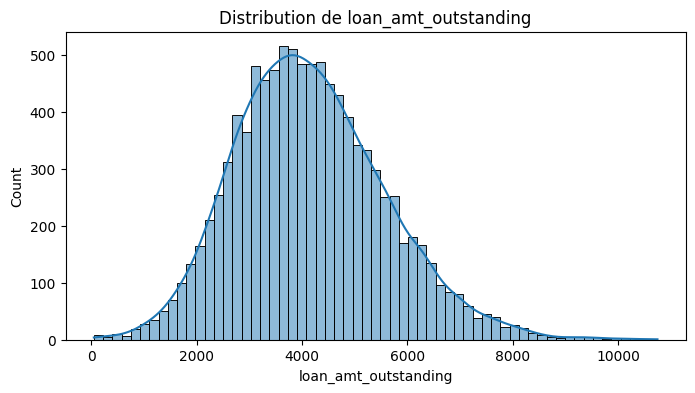

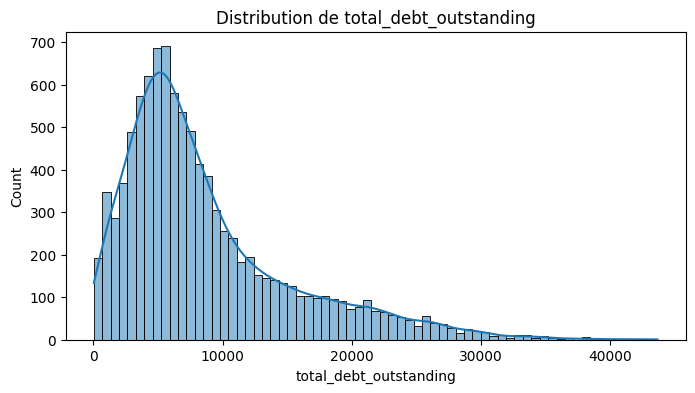

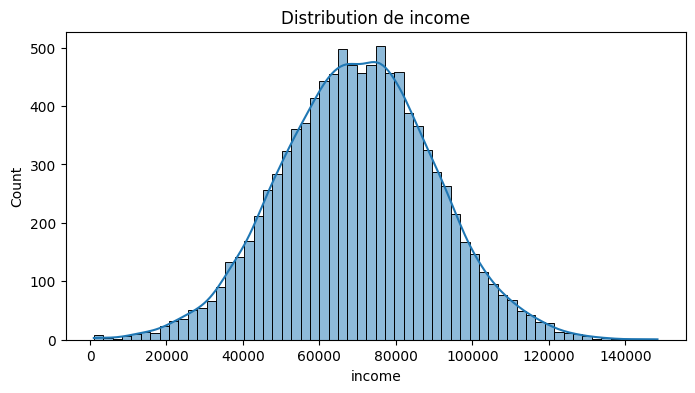

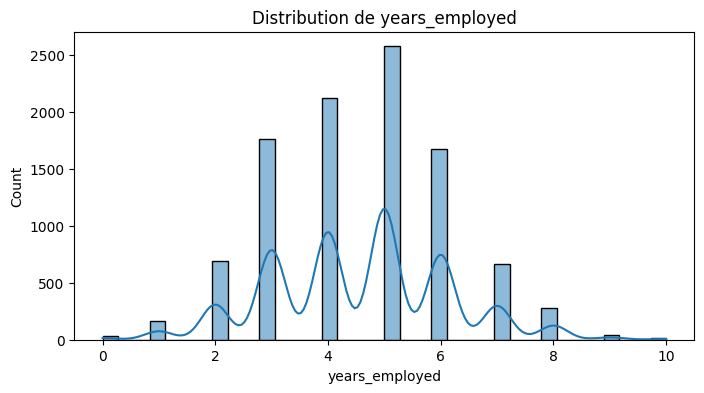

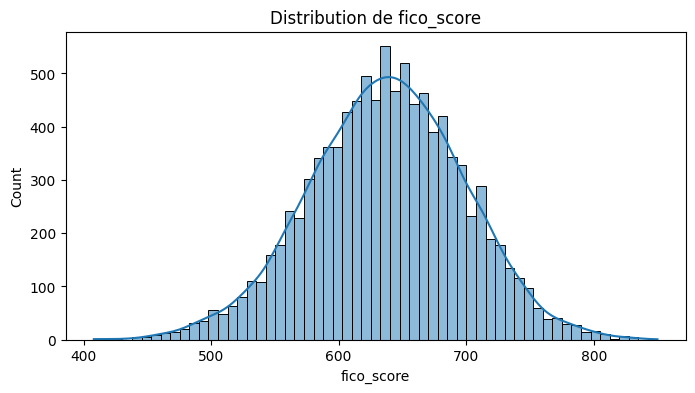

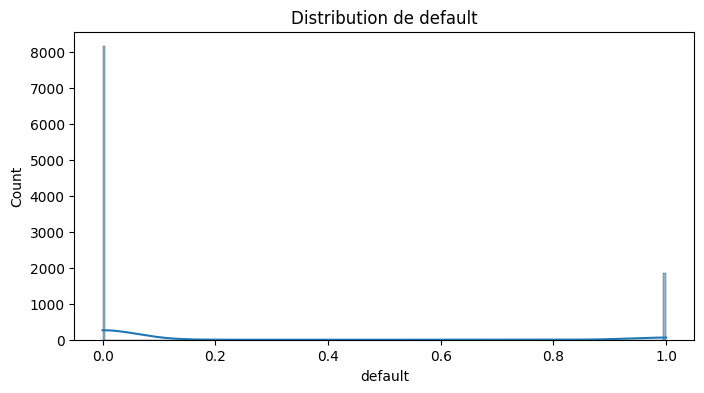

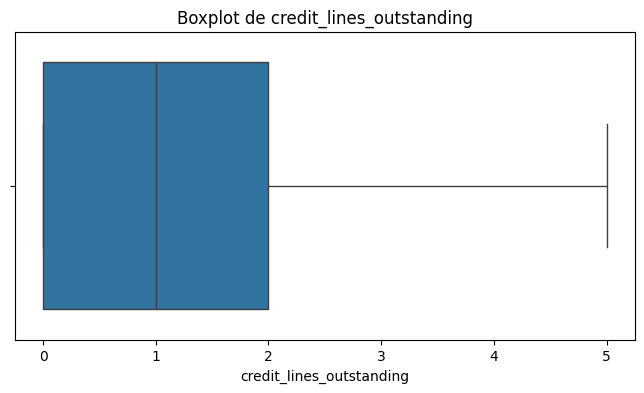

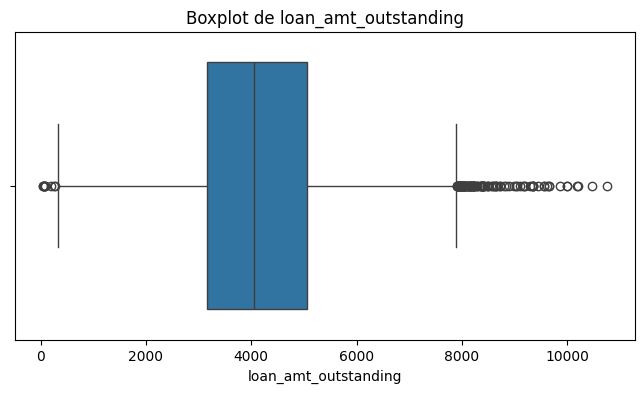

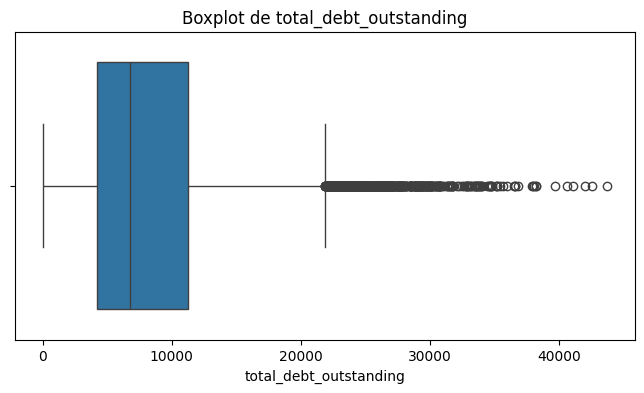

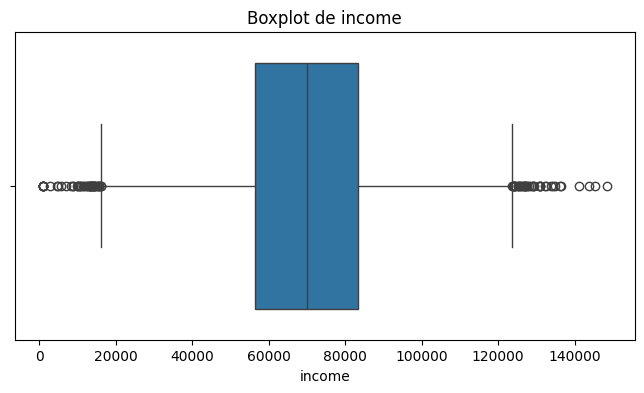

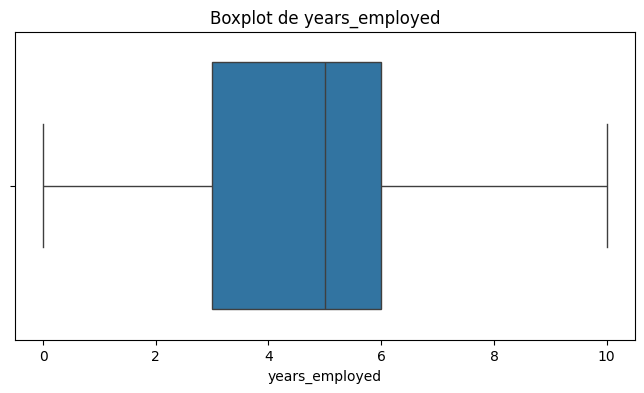

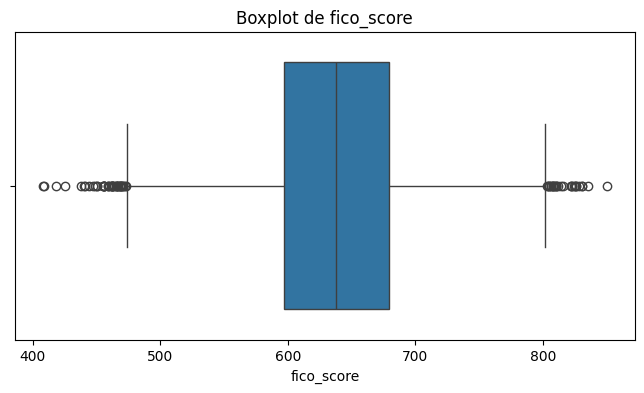

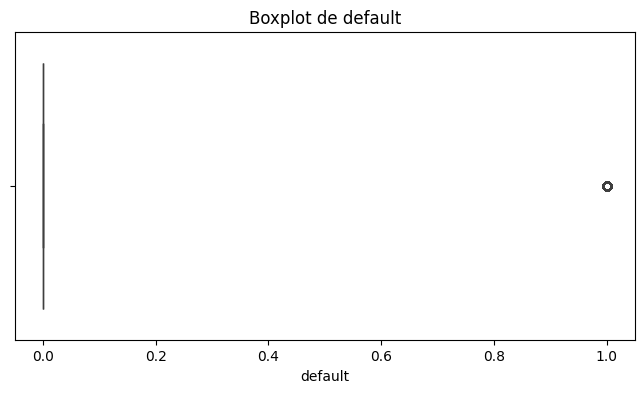

In [55]:

data_net= data.drop(columns=['customer_id'])


# Matrice de corrélation

plt.figure(figsize=(12, 10))   
sns.heatmap(data_net.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation') 
plt.show()
# liste des correlations > 0,8
correlation_matrix = data_net.corr()
high_correlation = correlation_matrix[correlation_matrix.abs()> 0.75]
print("Correlations supérieures à 0,75 :")
display(high_correlation)
# Matrice graphique de corrélation
sns.pairplot(data_net)
# Analyse de la distribution de la variable cible 'default'
sns.countplot(x='default', data=data_net)

# Visualisation de la distribution des variables numériques
#numeric_columns = data.select_dtypes(include=[np.number]).columns
for column in data_net:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution de {column}')

    plt.show()

# Analyse des outliers avec des boxplots
for column in data_net:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data_net[column])
    plt.title(f'Boxplot de {column}')
    plt.show()

In [59]:
#check
print(type(data_net.corr()))
display(data_net.corr().size)
display(data_net.corr().shape)  


<class 'pandas.DataFrame'>


49

(7, 7)

# Définition FICO score:
* Le score FICO est un indicateur de solvabilité largement utilisé aux États-Unis pour évaluer le risque de crédit d’un emprunteur. Il permet aux établissements financiers d’estimer la probabilité qu’une personne rembourse correctement ses dettes.
Ce score est généralement compris entre 300 et 850. Plus il est élevé, plus le profil de crédit est considéré comme fiable. Il est notamment pris en compte lors de demandes de carte bancaire, de prêt automobile, de crédit immobilier ou de prêt personnel.
Le calcul du score FICO repose sur plusieurs éléments du dossier de crédit, parmi lesquels figurent l’historique des paiements, le niveau d’endettement, l’ancienneté du crédit, le nombre de nouvelles demandes de crédit ainsi que la diversité des types de crédit utilisés.
À titre indicatif, un score supérieur à 800 est considéré comme excellent, entre 740 et 799 comme très bon, entre 670 et 739 comme bon, entre 580 et 669 comme moyen, et inférieur à 580 comme faible.*

In [47]:
# Paradoxe: le fixo_score est ici peu corréler au défault 

In [48]:
#suppression de la colonne 'default' 

data_vif= data_net.drop(columns=['default'])

print(data_vif.head())

   credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
0                         0           5221.545193             3915.471226   
1                         5           1958.928726             8228.752520   
2                         0           3363.009259             2027.830850   
3                         0           4766.648001             2501.730397   
4                         1           1345.827718             1768.826187   

        income  years_employed  fico_score  
0  78039.38546               5         605  
1  26648.43525               2         572  
2  65866.71246               4         602  
3  74356.88347               5         612  
4  23448.32631               6         631  


In [49]:
# Analyse VIF   
# Calcul du VIF pour chaque variable
from statsmodels.stats.outliers_influence import variance_inflation_factor   
vif_values = [variance_inflation_factor(data_vif.values, i) for i in range(data_vif.shape[1])]
for i in range(len(vif_values)):
    print(f"VIF for {data_vif.columns[i]}: {vif_values[i]}")     

VIF for credit_lines_outstanding: 10.9488455880746
VIF for loan_amt_outstanding: 35.08803552231979
VIF for total_debt_outstanding: 21.937163377951418
VIF for income: 59.93081187684781
VIF for years_employed: 11.896744233503542
VIF for fico_score: 22.404741558573658


In [50]:
# préparation des données pour la modélisation
X = data_net.drop(columns=['default'])
y = data_net['default']
display(X.shape)
display(y.shape)
display(y.head())
print(X.head())

(10000, 6)

(10000,)

0    0
1    1
2    0
3    0
4    0
Name: default, dtype: int64

   credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
0                         0           5221.545193             3915.471226   
1                         5           1958.928726             8228.752520   
2                         0           3363.009259             2027.830850   
3                         0           4766.648001             2501.730397   
4                         1           1345.827718             1768.826187   

        income  years_employed  fico_score  
0  78039.38546               5         605  
1  26648.43525               2         572  
2  65866.71246               4         602  
3  74356.88347               5         612  
4  23448.32631               6         631  


In [61]:
# Génaréation des données d'entraînement et de test / val sera traité par CV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 )

display(X_train.shape, y_train.shape,  X_test.shape, y_test.shape)

display(X_train.head())
display(y_train.head()) 

(8000, 6)

(8000,)

(2000, 6)

(2000,)

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score
2350,1,3502.046995,5211.179806,50276.68003,5,678
861,5,1445.240903,7831.909836,25976.41432,4,597
8672,4,4913.033478,18565.792280,70163.53787,3,649
4191,1,57.434185,118.051600,1000.00000,2,591
2844,4,2157.722248,9427.961238,37828.68024,3,555


2350    0
861     1
8672    1
4191    0
2844    1
Name: default, dtype: int64

c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



================ Logistic Regression ================
Best params: {'model__C': 10}
Best CV F1: 0.996623814244586
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       1.00      1.00      1.00       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


================ Random Forest ================
Best params: {'model__max_depth': 7, 'model__n_estimators': 100}
Best CV F1: 0.9837601466132373
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       0.99      0.99      0.99       370

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


================ XGBoost ================
Best params: {'model__max_depth': 7, 'model

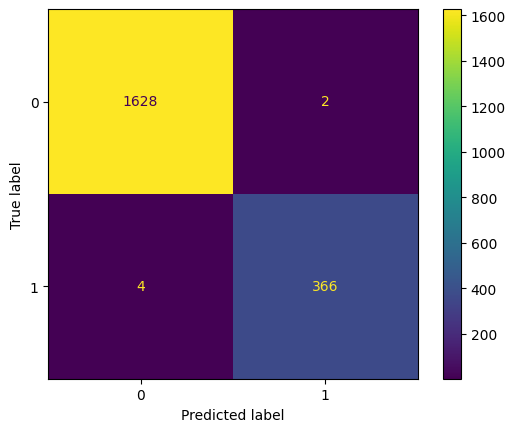

In [65]:
#création du pipeline de modélisation


models = {
    "Logistic Regression": LogisticRegression(
        solver="saga",      # obligatoire pour L1
        penalty="l1",
        max_iter=5000,
        random_state=seeds
    ),
    "Random Forest": RandomForestClassifier(
        random_state=seeds
    ),
    "XGBoost": XGBClassifier(
        random_state=seeds,
        eval_metric="logloss"
    ),
    "MLP Classifier": MLPClassifier(
        random_state=seeds,
        max_iter=500
    )
}


gridsearch_params = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7]
    },
    "MLP Classifier": {
        "model__hidden_layer_sizes": [(80, 50), (80,40,20), (60, 30)]
    }
}

# ====================================
#  Boucle GridSearchCV + évaluation
# ====================================
all_results = []

for name, model in models.items():
    # Pipeline = scaler + modèle
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=gridsearch_params[name],
        cv=5,
        scoring="f1",   # binaire
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_      # pipeline complet (scaler+model)
    y_pred = best_model.predict(X_test)     # pas besoin de scaler X_val: pipeline le fait

    print(f"\n================ {name} ================")
    print("Best params:", grid.best_params_) # affiche les meilleurs hyperparamètres du modèle refité sur l'ensemble du train
    print("Best CV F1:", grid.best_score_) # affiche le meilleur score CV (F1) obtenu avec ces hyperparamètres pendant la validation croisée
    print(classification_report(y_test, y_pred))  # affiche le rapport de classification sur le test set (y_test    ) avec les prédictions du modèle refité (y_pred)

    # Stockage des cv_results_ (toutes les configs testées)
    cv_df = pd.DataFrame(grid.cv_results_)
    cv_df["model_name"] = name
    all_results.append(cv_df)

# ====================================
#  Tableau global: top configurations
# ====================================

confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred) 


#results_df = pd.concat(all_results, ignore_index=True)
top = (
    results_df[["model_name", "rank_test_score", "mean_test_score", "std_test_score", "params"]]
    .sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])
    .head(15)
)
print("\nTOP 15 configs (tous modèles):")
print(top.to_string(index=False))